In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df=pd.read_pickle(r'/content/drive/MyDrive/LSWMD.pkl')

In [3]:
raw=df

In [6]:
import numpy as np
data = pd.DataFrame({
    'waferMap'   : raw['waferMap'].values,
    'failureType': raw['failureType'].values
})
# ── Clean labels for ALL 811K rows ───────────────────────────────────────────
def extract_label(x):
    val = np.squeeze(x)
    if val.ndim == 0: return str(val).strip()
    if val.size  == 0: return 'unlabeled'
    return str(val.flat[0]).strip()

data['failureType'] = data['failureType'].apply(extract_label)
data.loc[data['failureType'].isin(['', '[]', 'nan']), 'failureType'] = 'unlabeled'

# ✅ 9-CLASS FIX: Keep Loc and Edge-Loc as SEPARATE classes.
# Previous notebooks merged them to reduce confusion, but that hides
# real defect information. With proper augmentation + Focal Loss,
# the model can distinguish them reliably.

print('Label distribution (ALL 811K rows):')
print(data['failureType'].value_counts())
print(f'\nTotal     : {len(data):,}')
print(f'Labeled   : {(data["failureType"] != "unlabeled").sum():,}')
print(f'Unlabeled : {(data["failureType"] == "unlabeled").sum():,}')


Label distribution (ALL 811K rows):
failureType
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Total     : 811,457
Labeled   : 172,950
Unlabeled : 638,507


In [7]:
NUM_CLASSES = 9
CLASS_NAMES=[
    # ✅ Matches LabelEncoder alphabetical sort used during training
    'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
    'Loc', 'Near-full', 'Random', 'Scratch', 'none'
]

In [8]:
labeled_data = data[data['failureType'].isin(CLASS_NAMES)].reset_index(drop=True)

In [9]:
import math, torch.nn as nn, torch

In [10]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
# ── Re-define the model architecture (must match training) ────────────────────
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=9, img_size=64, d_model=256, nhead=8, num_layers=4, dropout=0.5):
        super().__init__()
        self.img_size = img_size
        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.ReLU(),
        )
        feat_h = img_size // 4
        seq_len = feat_h * feat_h
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.cnn_backbone(x)
        B, C, H, W = feat.shape
        feat = feat.flatten(2).transpose(1, 2)
        feat = feat + self.pos_embed[:, :feat.size(1), :]
        feat = self.transformer(feat)
        feat = feat.mean(dim=1)
        return self.head(feat)

# Re-create the Hybrid Model with the massive Dropout penalty activated
hybrid_model = HybridCNNTransformer(NUM_CLASSES, dropout=0.5).to(DEVICE)
total_params_h = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)

#@st.cache_resource
def load_model():
    # Pass dropout=0.5 explicitly for architectural match!
    model = HybridCNNTransformer(len(CLASS_NAMES), dropout=0.5).to(DEVICE)
    model.load_state_dict(torch.load("best_hybrid.pth", map_location=DEVICE, weights_only=True))
    model.eval()
    return model


In [65]:
import torch.nn as nn

class WaferCNN(nn.Module):
    """Upgraded 5-block CNN for deeper 9-class wafer defect classification."""
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — low-level edges & textures
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Dropout2d(0.2), # Intentionally skipped max-pooling here to preserve resolution

            # Block 5 — 🔥 NEW LAYER added here!
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Dropout2d(0.3),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            # The input size changed from 256 to 512 because we added Block 5
            nn.Linear(512, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))




In [66]:
# ── ViT built from scratch — NO timm, NO HuggingFace, NO internet needed ─────
import math, torch.nn as nn, torch

class PatchEmbed(nn.Module):
    """Split 224×224 image into 196 patches of 16×16, project to embed_dim."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class ViTAttention(nn.Module):
    def __init__(self, embed_dim=192, num_heads=3, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3)
        self.proj      = nn.Linear(embed_dim, embed_dim)
        self.dropout   = nn.Dropout(dropout)
    def forward(self, x):
        B, N, C = x.shape
        qkv  = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = self.dropout((q @ k.transpose(-2,-1)) * self.scale).softmax(dim=-1)
        return self.proj((attn @ v).transpose(1,2).reshape(B, N, C))

class ViTBlock(nn.Module):
    def __init__(self, embed_dim=192, num_heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = ViTAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim    = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class WaferViT(nn.Module):
    """ViT-Tiny: patch16, embed_dim=192, depth=12, heads=3. No pretrained needed."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3,
                 embed_dim=192, depth=12, num_heads=3,
                 mlp_ratio=4.0, num_classes=9, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)
        num_patches      = self.patch_embed.num_patches
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches+1, embed_dim))
        self.pos_drop    = nn.Dropout(dropout)
        self.blocks      = nn.Sequential(*[
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        B   = x.shape[0]
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.pos_drop(torch.cat([cls, x], dim=1) + self.pos_embed)
        x   = self.norm(self.blocks(x))
        return self.head(x[:, 0])



In [67]:
cnn_model = WaferCNN(NUM_CLASSES).to(DEVICE)
vit_model = WaferViT(num_classes=NUM_CLASSES).to(DEVICE)
hybrid_model = HybridCNNTransformer().to(DEVICE)

# 🔥 CHANGE PATH to your actual file
CNN_MODEL_PATH = "/content/drive/MyDrive/best_cnn.pth"
VIT_MODEL_PATH = "/content/drive/MyDrive/best_vit.pth"
HYBRID_MODEL_PATH = "/content/drive/MyDrive/best_hybrid.pth"

cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=DEVICE))
cnn_model.eval()

vit_model.load_state_dict(torch.load(VIT_MODEL_PATH, map_location=DEVICE))
vit_model.eval()

hybrid_model.load_state_dict(torch.load(HYBRID_MODEL_PATH, map_location=DEVICE))
hybrid_model.eval()

print("✅ Model's loaded successfully")

✅ Model's loaded successfully


In [68]:
GDRIVE_BASE = '/content/drive/MyDrive'
SAVE_DIR = 'content/wafer_imgs'

In [84]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def get_yolo_bbox_largest_defect(wafer):
    arr = np.array(wafer, dtype=np.uint8)
    defect_mask = np.where(arr == 2, 255, 0).astype(np.uint8)
    contours, _ = cv2.findContours(defect_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    img_h, img_w = arr.shape
    x_center_norm = (x + w / 2.0) / img_w
    y_center_norm = (y + h / 2.0) / img_h
    w_norm        = w / img_w
    h_norm        = h / img_h
    return [x_center_norm, y_center_norm, w_norm, h_norm]


def get_model_input_size(model):
    # ViT: has patch_embed → derive size from num_patches and patch_size
    if hasattr(model, 'patch_embed'):
        num_patches = model.patch_embed.num_patches
        patch_size  = model.patch_embed.proj.kernel_size[0]
        return int(num_patches ** 0.5) * patch_size   # e.g. 14 * 16 = 224
    # CNN / Hybrid: has explicit img_size attribute
    if hasattr(model, 'img_size'):
        return model.img_size
    return 64  # fallback


def predict_input(model, yolo_model, class_names,
                  disk_idx=None, uploaded_img=None, show_ground_truth=True,
                  raw_wafer=None, model_name=None):

    # ── Auto-detect model name ─────────────────────────────────────────────────
    if model_name is None:
        cls = type(model).__name__
        if   'CNN' in cls and 'Transformer' in cls: model_name = "Hybrid"
        elif 'ViT' in cls or 'Transformer' in cls:  model_name = "ViT"
        elif 'CNN' in cls:                           model_name = "CNN"
        else:                                        model_name = cls

    # ── Auto-detect required input size ───────────────────────────────────────
    target_size = get_model_input_size(model)

    # ── 1. Load Image ──────────────────────────────────────────────────────────
    if uploaded_img is not None:
        img = uploaded_img
    elif disk_idx is not None:
        img = np.load(f'{SAVE_DIR}/{disk_idx:06d}.npy')
    else:
        raise ValueError("Provide either disk_idx or uploaded_img")

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    # ── Resize to what THIS model expects ─────────────────────────────────────
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    img_resized = cv2.resize(
        (img * 255).astype(np.uint8),
        (target_size, target_size),
        interpolation=cv2.INTER_NEAREST
    )
    img_rgb = img_resized
    img_f   = img_resized.astype(np.float32) / 255.0

    # ── 2. Predict ─────────────────────────────────────────────────────────────
    tensor = torch.tensor(img_f).permute(2,0,1).unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]

    pred_cls   = class_names[np.argmax(probs)]
    confidence = probs.max()

    # ── 3. Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img_rgb, cmap='plasma')
    axes[0].set_title(f"{model_name} — Input Wafer ({target_size}×{target_size})")
    axes[0].axis('off')



    axes[1].imshow(img_rgb, cmap='plasma')
    axes[1].set_title("Defect Bounding Box")
    axes[1].axis('off')

    # ── 4. Bounding Box ────────────────────────────────────────────────────────
    if show_ground_truth and raw_wafer is not None:
        bbox = get_yolo_bbox_largest_defect(raw_wafer)
        if bbox is not None:
            img_h, img_w = img_rgb.shape[:2]
            xc, yc, bw, bh = bbox
            abs_x = (xc - bw / 2) * img_w
            abs_y = (yc - bh / 2) * img_h
            abs_w = bw * img_w
            abs_h = bh * img_h
            rect = patches.Rectangle(
                (abs_x, abs_y), abs_w, abs_h,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            axes[1].add_patch(rect)

    axes[2].barh(class_names, probs)
    axes[2].set_xlim(0, 1)
    axes[2].set_title(f'{model_name} Class: {pred_cls} ({confidence:.2%})')

    plt.tight_layout()
    plt.show()
    return pred_cls, confidence

In [103]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

Saving Edge-Loc_1646.jpg to Edge-Loc_1646.jpg


In [104]:
import cv2
import numpy as np

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (64, 64), interpolation=cv2.INTER_NEAREST)
img = img / 255.0

# ── Build raw_wafer from uploaded image so get_yolo_bbox_largest_defect works ──
# Uploaded images are rendered PNGs — we recover the 0/1/2 wafer encoding
# by thresholding grayscale brightness:#   background (black)  → 0
#   good die (gray)     → 1
#   defect (bright)     → 2   ← this is what get_yolo_bbox_largest_defect needs
gray_raw  = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
raw_wafer = np.zeros_like(gray_raw, dtype=np.uint8)
raw_wafer[gray_raw > 30]  = 1   # wafer die area
raw_wafer[gray_raw > 180] = 2   # bright pixels = defect region


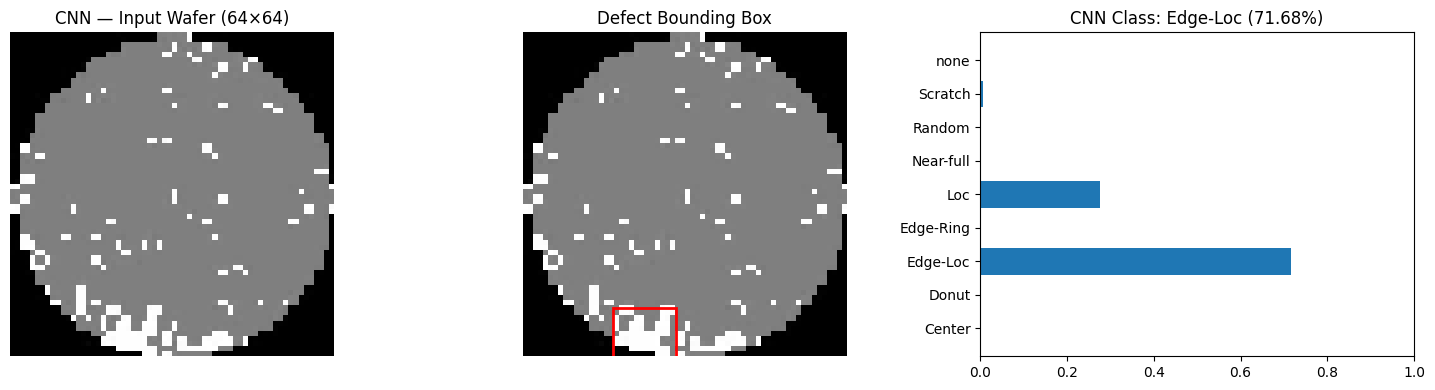

('Edge-Loc', np.float32(0.7167714))

In [105]:
predict_input(
    model=cnn_model,
    yolo_model=None,
    class_names=CLASS_NAMES,
    uploaded_img=img,
    raw_wafer=raw_wafer    # ← pass raw_wafer so bbox works on uploaded images
)


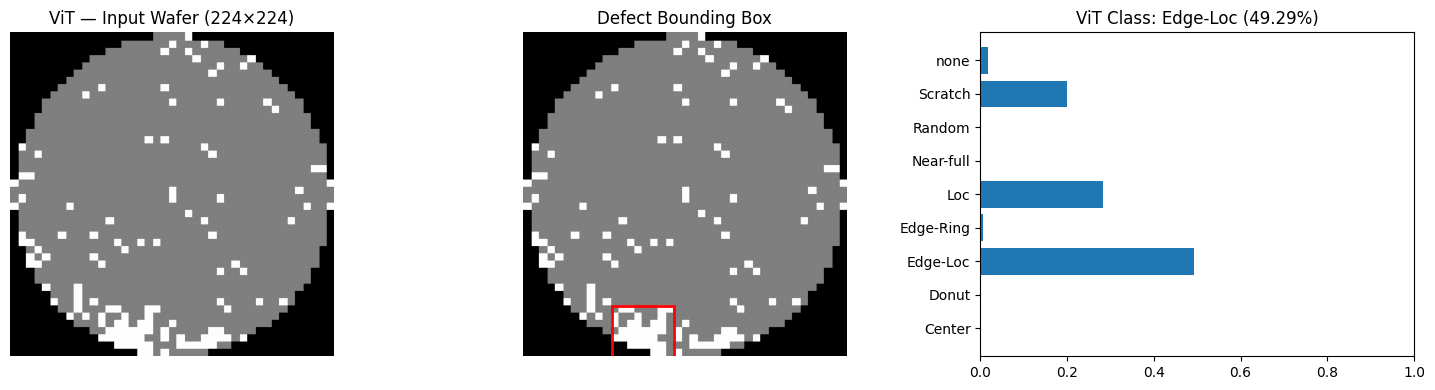

('Edge-Loc', np.float32(0.49290782))

In [106]:
predict_input(
    model=vit_model,
    yolo_model=None,
    class_names=CLASS_NAMES,
    uploaded_img=img,
    raw_wafer=raw_wafer    # ← pass raw_wafer so bbox works on uploaded images
)


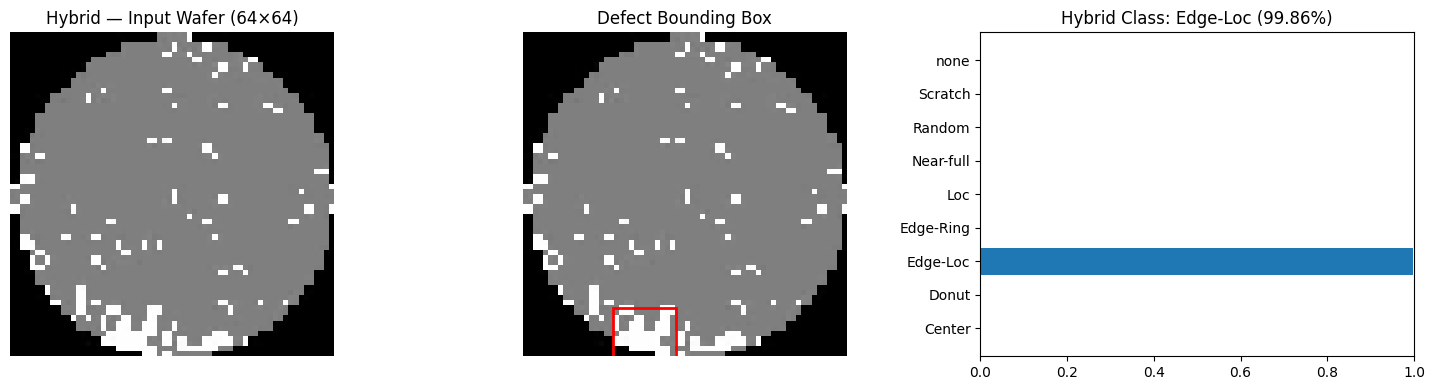

('Edge-Loc', np.float32(0.99855214))

In [107]:
predict_input(
    model=hybrid_model,
    yolo_model=None,
    class_names=CLASS_NAMES,
    uploaded_img=img,
    raw_wafer=raw_wafer    # ← pass raw_wafer so bbox works on uploaded images
)
